In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from scipy.spatial.distance import cdist
import time

# ============================================================
# CONFIGURATION
# ============================================================

np.random.seed(42)

# input_csv = "input_data.csv"
# output_csv = "output_data.csv"

# Rossler data
input_csv = "input_data_rossler.csv"
output_csv = "output_data_rossler.csv"

num_train_samples = 8000

# Keep N fixed to remove the reservoir-size confounder
N_fixed = 150

# Number of initial conditions for empirical separated-orbit estimate
M_initial_conditions = 500

# Integration settings
t_initial = 0.0
t_final = 1.0
num_eval_points = 500

# Use final trajectory length for main comparison
n_values = [500]

# Epsilon values for empirical Bowen-Dinaburg separated-orbit estimate
# eps_values = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
eps_values = [0.9, 0.5, 0.1, 0.05, 1e-2, 1e-4, 1e-6, 1e-10]

# Number of greedy repeats for approximating separated set size
n_greedy_repeats = 50

# Number of random seeds per regime
num_random_seeds = 30

# Same R range as before
R_low, R_high = 1.0, 30.0

# ============================================================
# LOAD DATA
# ============================================================

input_data = pd.read_csv(input_csv).iloc[:, 1:num_train_samples+1].values
output_data = pd.read_csv(output_csv).iloc[:, 1:num_train_samples+1].values

D, M, P = input_data.shape[1], input_data.shape[0], output_data.shape[0]

scaler_input = StandardScaler()
input_data_norm = scaler_input.fit_transform(input_data.T).T

scaler_output = StandardScaler()
output_data_norm = scaler_output.fit_transform(output_data.T).T

print("input_data_norm shape:", input_data_norm.shape)
print("D samples:", D, "M input features:", M, "P output features:", P)

# ============================================================
# LORENZ SYSTEM
# ============================================================

def lorenz_system(t, X, params):
    """
    Multiplexed Lorenz system.

    Parameter order:
        params[:, 0] = sigma
        params[:, 1] = beta
        params[:, 2] = rho
        params[:, 3] = tau
    """

    X = X.reshape(len(params), 3)

    sigma = params[:, 0]
    beta = params[:, 1]
    rho = params[:, 2]
    tau = params[:, 3]

    dxdt = (1.0 / tau) * sigma * (X[:, 1] - X[:, 0])
    dydt = (1.0 / tau) * (X[:, 0] * (rho - X[:, 2]) - X[:, 1])
    dzdt = (1.0 / tau) * (X[:, 0] * X[:, 1] - beta * X[:, 2])

    return np.stack([dxdt, dydt, dzdt], axis=1).flatten()


# ============================================================
# PARAMETER REGIMES
# ============================================================

def generate_lorenz_params_by_regime(N, regime, rng):
    """
    Generate Lorenz reservoir parameters for different dynamical regimes.

    The point is to keep N fixed and vary only the reservoir dynamics.
    """

    if regime == "low_rho_nonchaotic":
        # Mostly non-chaotic / stable regime
        sigma_range = (9.9, 10.1)
        beta_range = (2.65, 2.70)
        rho_range = (5.0, 15.0)
        tau_range = (1.0, 10.0)

    elif regime == "moderate_rho":
        # More dynamic but generally below classical chaotic regime
        sigma_range = (9.9, 10.1)
        beta_range = (2.65, 2.70)
        rho_range = (15.0, 22.0)
        tau_range = (1.0, 10.0)

    elif regime == "near_transition":
        # Near transition toward chaos
        sigma_range = (9.9, 10.1)
        beta_range = (2.65, 2.70)
        rho_range = (22.0, 26.0)
        tau_range = (1.0, 10.0)

    elif regime == "standard_chaotic":
        # Narrow range around standard Lorenz chaotic parameters
        sigma_range = (9.9, 10.1)
        beta_range = (2.65, 2.70)
        rho_range = (27.9, 28.1)
        tau_range = (1.0, 10.0)

    elif regime == "broad_chaotic":
        # Broader heterogeneous chaotic-like regime
        sigma_range = (8.0, 12.0)
        beta_range = (2.3, 3.1)
        rho_range = (28.0, 35.0)
        tau_range = (0.5, 15.0)

    else:
        raise ValueError(f"Unknown regime: {regime}")

    params = np.array([
        [
            rng.uniform(*sigma_range),
            rng.uniform(*beta_range),
            rng.uniform(*rho_range),
            rng.uniform(*tau_range)
        ]
        for _ in range(N)
    ])

    return params


# Ordered from less chaotic to more chaotic
regimes = [
    "low_rho_nonchaotic",
    "moderate_rho",
    "near_transition",
    "standard_chaotic",
    "broad_chaotic"
]


# ============================================================
# EMPIRICAL BOWEN-DINABURG FUNCTIONS
# ============================================================

def global_standardize_trajectory_list(trajectory_list):
    """
    Standardize all trajectories together using one global mean and std.
    This is important because we compare different parameter regimes.
    """

    all_flat = []

    for trajectories in trajectory_list:
        A, T, dim = trajectories.shape
        all_flat.append(trajectories.reshape(A * T, dim))

    all_flat = np.vstack(all_flat)

    mean = all_flat.mean(axis=0)
    std = all_flat.std(axis=0)
    std[std < 1e-12] = 1.0

    standardized_list = []

    for trajectories in trajectory_list:
        A, T, dim = trajectories.shape
        flat = trajectories.reshape(A * T, dim)
        flat_z = (flat - mean) / std
        standardized_list.append(flat_z.reshape(A, T, dim))

    return standardized_list


def bowen_dinaburg_distance_matrix(trajectories):
    """
    d_n(i,j) = max_t ||x_i(t) - x_j(t)|| / sqrt(dim)
    """

    A, T, dim = trajectories.shape
    Dmat = np.zeros((A, A), dtype=float)

    for t in range(T):
        Xt = trajectories[:, t, :]
        Dt = cdist(Xt, Xt, metric="euclidean") / np.sqrt(dim)
        Dmat = np.maximum(Dmat, Dt)

    return Dmat


def greedy_separated_count(Dmat, epsilon, order):
    """
    Greedy approximation to an epsilon-separated set.
    """

    selected = []

    for idx in order:
        if len(selected) == 0:
            selected.append(idx)
        else:
            if np.all(Dmat[idx, selected] > epsilon):
                selected.append(idx)

    return len(selected)


def estimate_separated_set_size(Dmat, epsilon, n_repeats=50, seed=42):
    """
    Estimate S(n, epsilon) using repeated greedy orderings.
    """

    rng = np.random.default_rng(seed)
    A = Dmat.shape[0]

    counts = []

    counts.append(greedy_separated_count(Dmat, epsilon, np.arange(A)))
    counts.append(greedy_separated_count(Dmat, epsilon, np.arange(A)[::-1]))

    for _ in range(n_repeats):
        order = rng.permutation(A)
        counts.append(greedy_separated_count(Dmat, epsilon, order))

    counts = np.asarray(counts)

    return int(np.max(counts)), counts


def empirical_bd_entropy_from_trajectories(
    trajectories,
    eps_values,
    n_values,
    n_greedy_repeats=50,
    seed=42
):
    """
    Empirical finite-time Bowen-Dinaburg separated-orbit entropy estimate.

    h_hat(n, epsilon) = log(S(n, epsilon)) / n
    """

    results = []
    A, T_total, dim = trajectories.shape

    for n in n_values:
        if n > T_total:
            continue

        traj_n = trajectories[:, :n, :]
        Dmat = bowen_dinaburg_distance_matrix(traj_n)

        for eps in eps_values:
            S_sep, greedy_counts = estimate_separated_set_size(
                Dmat,
                epsilon=eps,
                n_repeats=n_greedy_repeats,
                seed=seed + n
            )

            h_hat = np.log(S_sep) / n

            results.append({
                "trajectory_length_n": n,
                "epsilon": eps,
                "num_initial_conditions": A,
                "state_dimension": dim,
                "separated_set_size": S_sep,
                "empirical_bd_entropy": h_hat,
                "finite_ensemble_bound_logM_over_n": np.log(A) / n,
                "greedy_count_mean": np.mean(greedy_counts),
                "greedy_count_std": np.std(greedy_counts, ddof=1),
                "greedy_count_min": np.min(greedy_counts),
                "greedy_count_max": np.max(greedy_counts)
            })

    return pd.DataFrame(results)

/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


input_data_norm shape: (3, 8000)
D samples: 8000 M input features: 3 P output features: 3



Running seed 1/30

Simulating regime: low_rho_nonchaotic
  trajectory 1/500
  trajectory 26/500
  trajectory 51/500
  trajectory 76/500
  trajectory 101/500
  trajectory 126/500
  trajectory 151/500
  trajectory 176/500
  trajectory 201/500
  trajectory 226/500
  trajectory 251/500
  trajectory 276/500
  trajectory 301/500
  trajectory 326/500
  trajectory 351/500
  trajectory 376/500
  trajectory 401/500
  trajectory 426/500
  trajectory 451/500
  trajectory 476/500
  trajectories shape: (500, 500, 450)

Simulating regime: moderate_rho
  trajectory 1/500
  trajectory 26/500
  trajectory 51/500
  trajectory 76/500
  trajectory 101/500
  trajectory 126/500
  trajectory 151/500
  trajectory 176/500
  trajectory 201/500
  trajectory 226/500
  trajectory 251/500
  trajectory 276/500
  trajectory 301/500
  trajectory 326/500
  trajectory 351/500
  trajectory 376/500
  trajectory 401/500
  trajectory 426/500
  trajectory 451/500
  trajectory 476/500
  trajectories shape: (500, 500, 450)

Si

,regime,epsilon,trajectory_length_n,mean_entropy,std_entropy,median_entropy,mean_separated_set_size,std_separated_set_size,mean_bound
8,low_rho_nonchaotic,1.000000e-10,500,0.012225,0.000022,0.01223,451.433333,4.868501,0.012429
16,moderate_rho,1.000000e-10,500,0.012225,0.000022,0.01223,451.433333,4.868501,0.012429
24,near_transition,1.000000e-10,500,0.012225,0.000022,0.01223,451.433333,4.868501,0.012429
32,standard_chaotic,1.000000e-10,500,0.012225,0.000022,0.01223,451.433333,4.868501,0.012429
0,broad_chaotic,1.000000e-10,500,0.012225,0.000022,0.01223,451.433333,4.868501,0.012429


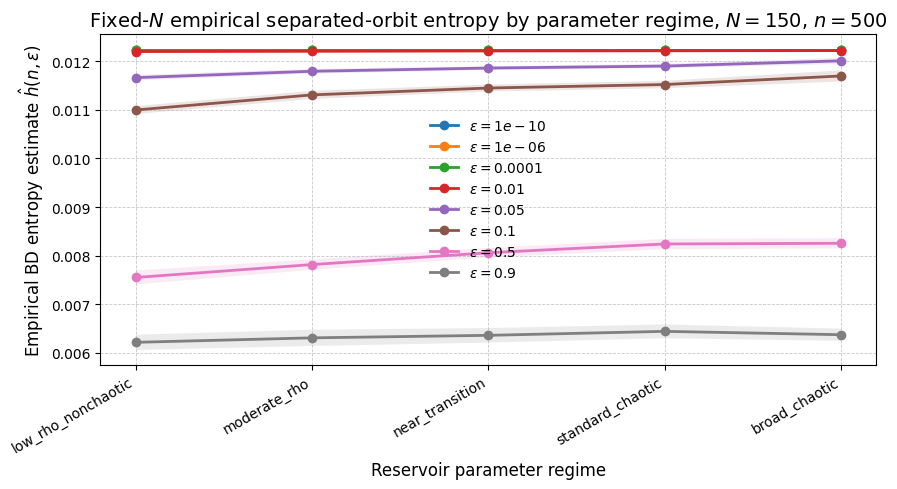

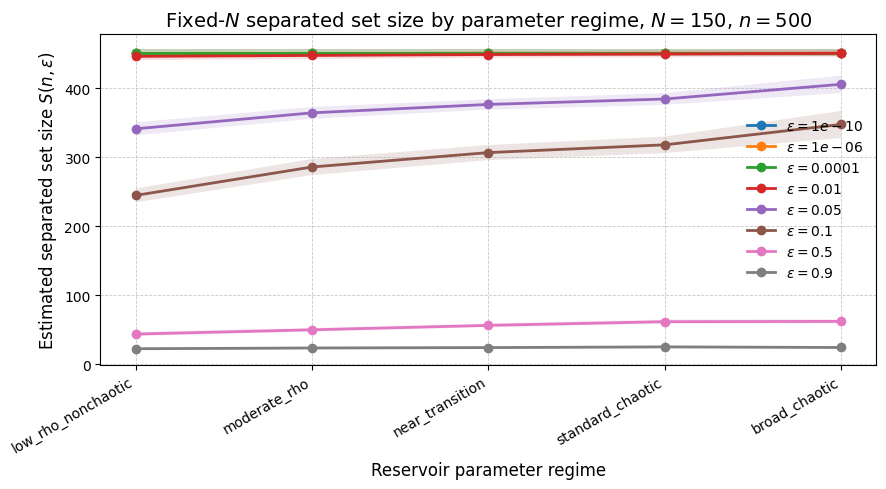

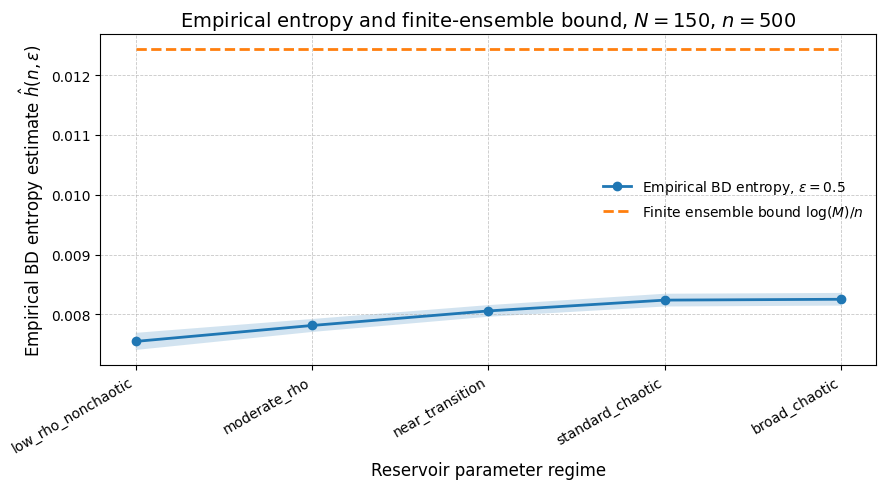

In [2]:
# ============================================================
# RUN FIXED-N REGIME ANALYSIS
# ============================================================

start_time = time.time()

all_seed_results = []

for seed_id in range(num_random_seeds):
    print("\n" + "=" * 90)
    print(f"Running seed {seed_id + 1}/{num_random_seeds}")
    print("=" * 90)

    rng = np.random.default_rng(1000 + seed_id)

    # Use the same selected samples and same R for all regimes within this seed.
    A = min(M_initial_conditions, D)
    selected_indices = rng.choice(D, size=A, replace=False)

    R = rng.uniform(R_low, R_high, size=(3 * N_fixed, M))

    initial_conditions = []

    for idx in selected_indices:
        u = input_data_norm[:, idx]
        x0 = R @ u
        initial_conditions.append(x0)

    initial_conditions = np.asarray(initial_conditions)

    t_eval = np.linspace(t_initial, t_final, num_eval_points)

    # First simulate all regimes for this seed.
    regime_trajectories = []
    regime_names_successful = []

    for regime in regimes:
        print(f"\nSimulating regime: {regime}")

        params_rng = np.random.default_rng(5000 + seed_id)
        reservoir_params = generate_lorenz_params_by_regime(
            N=N_fixed,
            regime=regime,
            rng=params_rng
        )

        trajectories = []

        for count, x0 in enumerate(initial_conditions):
            if count % 25 == 0:
                print(f"  trajectory {count + 1}/{A}")

            sol = solve_ivp(
                lorenz_system,
                (t_initial, t_final),
                x0,
                t_eval=t_eval,
                args=(reservoir_params,),
                method="RK45",
                rtol=1e-6,
                atol=1e-9
            )

            if sol.success:
                trajectories.append(sol.y.T)
            else:
                print(f"  Warning: integration failed for trajectory {count}")

        trajectories = np.asarray(trajectories)

        if trajectories.shape[0] >= 2:
            regime_trajectories.append(trajectories)
            regime_names_successful.append(regime)
            print("  trajectories shape:", trajectories.shape)
        else:
            print(f"  Skipping regime {regime}: fewer than 2 successful trajectories")

    # Global standardization across all regimes for fair distance comparison.
    regime_trajectories_z = global_standardize_trajectory_list(regime_trajectories)

    # Now compute empirical BD entropy for each regime.
    for regime, trajectories_z in zip(regime_names_successful, regime_trajectories_z):
        print(f"\nComputing empirical BD entropy for regime: {regime}")

        entropy_df = empirical_bd_entropy_from_trajectories(
            trajectories=trajectories_z,
            eps_values=eps_values,
            n_values=n_values,
            n_greedy_repeats=n_greedy_repeats,
            seed=9000 + seed_id
        )

        entropy_df["N"] = N_fixed
        entropy_df["regime"] = regime
        entropy_df["seed_id"] = seed_id
        entropy_df["t_initial"] = t_initial
        entropy_df["t_final"] = t_final
        entropy_df["num_eval_points"] = num_eval_points

        all_seed_results.append(entropy_df)

# Save raw results
fixed_N_regime_entropy_df = pd.concat(all_seed_results, ignore_index=True)

fixed_N_regime_entropy_df.to_csv(
    "fixed_N_empirical_BD_entropy_by_parameter_regime.csv",
    index=False
)

print("\nSaved: fixed_N_empirical_BD_entropy_by_parameter_regime.csv")
print(f"Total time: {time.time() - start_time:.2f} seconds")

# ============================================================
# SUMMARIZE ACROSS SEEDS
# ============================================================

summary_df = (
    fixed_N_regime_entropy_df
    .groupby(["regime", "epsilon", "trajectory_length_n"], as_index=False)
    .agg(
        mean_entropy=("empirical_bd_entropy", "mean"),
        std_entropy=("empirical_bd_entropy", "std"),
        median_entropy=("empirical_bd_entropy", "median"),
        mean_separated_set_size=("separated_set_size", "mean"),
        std_separated_set_size=("separated_set_size", "std"),
        mean_bound=("finite_ensemble_bound_logM_over_n", "mean")
    )
)

# Preserve regime order
summary_df["regime"] = pd.Categorical(
    summary_df["regime"],
    categories=regimes,
    ordered=True
)

summary_df = summary_df.sort_values(["epsilon", "trajectory_length_n", "regime"])

summary_df.to_csv(
    "summary_fixed_N_empirical_BD_entropy_by_parameter_regime.csv",
    index=False
)

print("Saved: summary_fixed_N_empirical_BD_entropy_by_parameter_regime.csv")
display(summary_df.head())

# ============================================================
# PLOT 1: ENTROPY BY REGIME
# ============================================================

plot_n = max(summary_df["trajectory_length_n"].unique())

plt.figure(figsize=(9, 5))

for eps in sorted(summary_df["epsilon"].unique()):
    df_plot = summary_df[
        (summary_df["epsilon"] == eps)
        & (summary_df["trajectory_length_n"] == plot_n)
    ].sort_values("regime")

    x = np.arange(len(df_plot))

    plt.plot(
        x,
        df_plot["mean_entropy"],
        marker="o",
        linewidth=2,
        label=rf"$\epsilon={eps}$"
    )

    plt.fill_between(
        x,
        df_plot["mean_entropy"] - df_plot["std_entropy"],
        df_plot["mean_entropy"] + df_plot["std_entropy"],
        alpha=0.15
    )

plt.xticks(
    np.arange(len(regimes)),
    regimes,
    rotation=30,
    ha="right"
)

plt.xlabel("Reservoir parameter regime", fontsize=12)
plt.ylabel(r"Empirical BD entropy estimate $\hat{h}(n,\epsilon)$", fontsize=12)
plt.title(
    rf"Fixed-$N$ empirical separated-orbit entropy by parameter regime, $N={N_fixed}$, $n={plot_n}$",
    fontsize=14
)
plt.legend(frameon=False, fontsize=10)
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()

plt.savefig(
    "fixed_N_empirical_BD_entropy_by_parameter_regime.jpeg",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PLOT 2: SEPARATED SET SIZE BY REGIME
# ============================================================

plt.figure(figsize=(9, 5))

for eps in sorted(summary_df["epsilon"].unique()):
    df_plot = summary_df[
        (summary_df["epsilon"] == eps)
        & (summary_df["trajectory_length_n"] == plot_n)
    ].sort_values("regime")

    x = np.arange(len(df_plot))

    plt.plot(
        x,
        df_plot["mean_separated_set_size"],
        marker="o",
        linewidth=2,
        label=rf"$\epsilon={eps}$"
    )

    plt.fill_between(
        x,
        df_plot["mean_separated_set_size"] - df_plot["std_separated_set_size"],
        df_plot["mean_separated_set_size"] + df_plot["std_separated_set_size"],
        alpha=0.15
    )

plt.xticks(
    np.arange(len(regimes)),
    regimes,
    rotation=30,
    ha="right"
)

plt.xlabel("Reservoir parameter regime", fontsize=12)
plt.ylabel(r"Estimated separated set size $S(n,\epsilon)$", fontsize=12)
plt.title(
    rf"Fixed-$N$ separated set size by parameter regime, $N={N_fixed}$, $n={plot_n}$",
    fontsize=14
)
plt.legend(frameon=False, fontsize=10)
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()

plt.savefig(
    "fixed_N_separated_set_size_by_parameter_regime.jpeg",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PLOT 3: SHOW FINITE ENSEMBLE BOUND
# ============================================================

plot_eps = 0.5

df_plot = summary_df[
    (summary_df["epsilon"] == plot_eps)
    & (summary_df["trajectory_length_n"] == plot_n)
].sort_values("regime")

x = np.arange(len(df_plot))

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    df_plot["mean_entropy"],
    marker="o",
    linewidth=2,
    label=rf"Empirical BD entropy, $\epsilon={plot_eps}$"
)

plt.fill_between(
    x,
    df_plot["mean_entropy"] - df_plot["std_entropy"],
    df_plot["mean_entropy"] + df_plot["std_entropy"],
    alpha=0.2
)

plt.plot(
    x,
    df_plot["mean_bound"],
    linestyle="--",
    linewidth=2,
    label=r"Finite ensemble bound $\log(M)/n$"
)

plt.xticks(
    x,
    df_plot["regime"],
    rotation=30,
    ha="right"
)

plt.xlabel("Reservoir parameter regime", fontsize=12)
plt.ylabel(r"Empirical BD entropy estimate $\hat{h}(n,\epsilon)$", fontsize=12)
plt.title(
    rf"Empirical entropy and finite-ensemble bound, $N={N_fixed}$, $n={plot_n}$",
    fontsize=14
)
plt.legend(frameon=False, fontsize=10)
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()

plt.savefig(
    "fixed_N_empirical_BD_entropy_with_finite_bound.jpeg",
    dpi=650,
    bbox_inches="tight"
)

plt.show()

In [3]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# ============================================================
# FIXED-N PREDICTION PERFORMANCE BY PARAMETER REGIME
# ============================================================

def compute_regression_metrics(y_true, y_pred):
    """
    Compute reviewer-requested regression metrics.

    y_true, y_pred shape:
        (num_outputs, num_samples)
    """

    yt = y_true.flatten()
    yp = y_pred.flatten()

    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)

    if np.std(yt) > 0 and np.std(yp) > 0:
        pearson_r, pearson_p = pearsonr(yt, yp)
    else:
        pearson_r, pearson_p = np.nan, np.nan

    # Calibration: predicted = slope * true + intercept
    if np.std(yt) > 0:
        calibration_slope, calibration_intercept = np.polyfit(yt, yp, 1)
    else:
        calibration_slope, calibration_intercept = np.nan, np.nan

    return {
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "calibration_slope": calibration_slope,
        "calibration_intercept": calibration_intercept
    }


def generate_reservoir_features_for_inputs(
    input_matrix_norm,
    R,
    reservoir_params,
    t_initial,
    t_final,
    num_eval_points
):
    """
    Generate final reservoir states for all input samples.

    input_matrix_norm shape:
        (num_input_features, num_samples)

    returns:
        X_reservoir shape: (3N, num_samples)
    """

    num_samples = input_matrix_norm.shape[1]
    t_eval = np.linspace(t_initial, t_final, num_eval_points)

    features = []

    for j in range(num_samples):
        if j % 100 == 0:
            print(f"    reservoir feature sample {j + 1}/{num_samples}")

        x0 = R @ input_matrix_norm[:, j]

        sol = solve_ivp(
            lorenz_system,
            (t_initial, t_final),
            x0,
            t_eval=t_eval,
            args=(reservoir_params,),
            method="RK45",
            rtol=1e-6,
            atol=1e-9
        )

        if not sol.success:
            raise RuntimeError(f"ODE integration failed for sample {j}")

        # final reservoir state
        features.append(sol.y[:, -1])

    return np.asarray(features).T


def train_readout_ridge(X_train, Y_train, alpha=1e-6):
    """
    Train linear readout Y = S X using ridge regression.

    X_train shape:
        (num_features, num_train_samples)

    Y_train shape:
        (num_outputs, num_train_samples)

    returns:
        trained Ridge model
    """

    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X_train.T, Y_train.T)

    return model


# ============================================================
# SETTINGS
# ============================================================

prediction_num_random_seeds = 30
test_fraction = 0.2
ridge_alpha_readout = 1e-6
ridge_alpha_baseline = 1.0

prediction_results = []

start_time = time.time()

for seed_id in range(prediction_num_random_seeds):

    print("\n" + "=" * 90)
    print(f"Prediction seed {seed_id + 1}/{prediction_num_random_seeds}")
    print("=" * 90)

    rng = np.random.default_rng(2000 + seed_id)

    all_indices = np.arange(D)
    rng.shuffle(all_indices)

    n_test = int(test_fraction * D)
    test_indices = all_indices[:n_test]
    train_indices = all_indices[n_test:]

    X_train_input = input_data_norm[:, train_indices]
    X_test_input = input_data_norm[:, test_indices]

    Y_train = output_data_norm[:, train_indices]
    Y_test = output_data_norm[:, test_indices]

    # Same R for all regimes within this seed
    R_fixed = rng.uniform(R_low, R_high, size=(3 * N_fixed, M))

    # ------------------------------------------------------------
    # Baseline 1: direct ridge regression input -> output
    # ------------------------------------------------------------

    ridge_baseline = Ridge(alpha=ridge_alpha_baseline, fit_intercept=True)
    ridge_baseline.fit(X_train_input.T, Y_train.T)

    Y_pred_ridge = ridge_baseline.predict(X_test_input.T).T
    ridge_metrics = compute_regression_metrics(Y_test, Y_pred_ridge)

    prediction_results.append({
        "seed_id": seed_id,
        "model": "direct_ridge_baseline",
        "regime": "baseline",
        "N": 0,
        **ridge_metrics
    })

    # ------------------------------------------------------------
    # Baseline 2: persistence, only valid if input and output dims match
    # ------------------------------------------------------------

    if X_test_input.shape[0] == Y_test.shape[0]:
        Y_pred_persistence = X_test_input.copy()
        persistence_metrics = compute_regression_metrics(Y_test, Y_pred_persistence)

        prediction_results.append({
            "seed_id": seed_id,
            "model": "persistence_baseline",
            "regime": "baseline",
            "N": 0,
            **persistence_metrics
        })

    # ------------------------------------------------------------
    # DynML fixed-N regimes
    # ------------------------------------------------------------

    for regime in regimes:

        print("\n" + "-" * 80)
        print(f"Running DynML prediction for regime: {regime}")
        print("-" * 80)

        params_rng = np.random.default_rng(6000 + seed_id)
        reservoir_params = generate_lorenz_params_by_regime(
            N=N_fixed,
            regime=regime,
            rng=params_rng
        )

        print("  generating train reservoir features")
        X_train_res = generate_reservoir_features_for_inputs(
            input_matrix_norm=X_train_input,
            R=R_fixed,
            reservoir_params=reservoir_params,
            t_initial=t_initial,
            t_final=t_final,
            num_eval_points=num_eval_points
        )

        print("  generating test reservoir features")
        X_test_res = generate_reservoir_features_for_inputs(
            input_matrix_norm=X_test_input,
            R=R_fixed,
            reservoir_params=reservoir_params,
            t_initial=t_initial,
            t_final=t_final,
            num_eval_points=num_eval_points
        )

        readout_model = train_readout_ridge(
            X_train=X_train_res,
            Y_train=Y_train,
            alpha=ridge_alpha_readout
        )

        Y_pred_test = readout_model.predict(X_test_res.T).T

        metrics = compute_regression_metrics(Y_test, Y_pred_test)

        prediction_results.append({
            "seed_id": seed_id,
            "model": "DynML_fixed_N",
            "regime": regime,
            "N": N_fixed,
            **metrics
        })

prediction_results_df = pd.DataFrame(prediction_results)

prediction_results_df.to_csv(
    "fixed_N_prediction_metrics_by_parameter_regime.csv",
    index=False
)

print("\nSaved: fixed_N_prediction_metrics_by_parameter_regime.csv")
print(f"Total prediction time: {time.time() - start_time:.2f} seconds")

display(prediction_results_df.head())


Prediction seed 1/30

--------------------------------------------------------------------------------
Running DynML prediction for regime: low_rho_nonchaotic
--------------------------------------------------------------------------------
  generating train reservoir features
    reservoir feature sample 1/6400
    reservoir feature sample 101/6400
    reservoir feature sample 201/6400
    reservoir feature sample 301/6400
    reservoir feature sample 401/6400
    reservoir feature sample 501/6400
    reservoir feature sample 601/6400
    reservoir feature sample 701/6400
    reservoir feature sample 801/6400
    reservoir feature sample 901/6400
    reservoir feature sample 1001/6400
    reservoir feature sample 1101/6400
    reservoir feature sample 1201/6400
    reservoir feature sample 1301/6400
    reservoir feature sample 1401/6400
    reservoir feature sample 1501/6400
    reservoir feature sample 1601/6400
    reservoir feature sample 1701/6400
    reservoir feature sample 18

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.190111100332548e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T



Prediction seed 20/30

--------------------------------------------------------------------------------
Running DynML prediction for regime: low_rho_nonchaotic
--------------------------------------------------------------------------------
  generating train reservoir features
    reservoir feature sample 1/6400
    reservoir feature sample 101/6400
    reservoir feature sample 201/6400
    reservoir feature sample 301/6400
    reservoir feature sample 401/6400
    reservoir feature sample 501/6400
    reservoir feature sample 601/6400
    reservoir feature sample 701/6400
    reservoir feature sample 801/6400
    reservoir feature sample 901/6400
    reservoir feature sample 1001/6400
    reservoir feature sample 1101/6400
    reservoir feature sample 1201/6400
    reservoir feature sample 1301/6400
    reservoir feature sample 1401/6400
    reservoir feature sample 1501/6400
    reservoir feature sample 1601/6400
    reservoir feature sample 1701/6400
    reservoir feature sample 1

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.978734986131284e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T



Prediction seed 21/30

--------------------------------------------------------------------------------
Running DynML prediction for regime: low_rho_nonchaotic
--------------------------------------------------------------------------------
  generating train reservoir features
    reservoir feature sample 1/6400
    reservoir feature sample 101/6400
    reservoir feature sample 201/6400
    reservoir feature sample 301/6400
    reservoir feature sample 401/6400
    reservoir feature sample 501/6400
    reservoir feature sample 601/6400
    reservoir feature sample 701/6400
    reservoir feature sample 801/6400
    reservoir feature sample 901/6400
    reservoir feature sample 1001/6400
    reservoir feature sample 1101/6400
    reservoir feature sample 1201/6400
    reservoir feature sample 1301/6400
    reservoir feature sample 1401/6400
    reservoir feature sample 1501/6400
    reservoir feature sample 1601/6400
    reservoir feature sample 1701/6400
    reservoir feature sample 1

,seed_id,model,regime,N,pearson_r,pearson_p,rmse,mae,r2,calibration_slope,calibration_intercept
0,0,direct_ridge_baseline,baseline,0,0.882986,0.0,0.468573,0.174787,0.779631,0.777209,-0.011709
1,0,persistence_baseline,baseline,0,0.707489,0.0,0.759670,0.420019,0.420778,0.700344,-0.006432
2,0,DynML_fixed_N,low_rho_nonchaotic,150,0.998573,0.0,0.053386,0.001912,0.997139,0.999756,0.000936
3,0,DynML_fixed_N,moderate_rho,150,0.998614,0.0,0.052743,0.002758,0.997208,1.001782,0.001163
4,0,DynML_fixed_N,near_transition,150,0.998923,0.0,0.046416,0.003166,0.997838,1.000848,0.000757


In [9]:
# ============================================================
# SUMMARIZE PREDICTION METRICS
# ============================================================

prediction_df = pd.read_csv("fixed_N_prediction_metrics_by_parameter_regime.csv")

summary_prediction_df = (
    prediction_df
    .groupby(["model", "regime"], as_index=False)
    .agg(
        mean_pearson_r=("pearson_r", "mean"),
        std_pearson_r=("pearson_r", "std"),
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        mean_calibration_slope=("calibration_slope", "mean"),
        std_calibration_slope=("calibration_slope", "std"),
        mean_calibration_intercept=("calibration_intercept", "mean"),
        std_calibration_intercept=("calibration_intercept", "std")
    )
)

summary_prediction_df.to_csv(
    "summary_fixed_N_prediction_metrics_by_parameter_regime.csv",
    index=False
)

display(summary_prediction_df)

# ============================================================
# LOAD ENTROPY SUMMARY AND MERGE WITH PREDICTION METRICS
# ============================================================

entropy_summary_df = pd.read_csv(
    "summary_fixed_N_empirical_BD_entropy_by_parameter_regime.csv"
)

# Choose one epsilon for combined plot.
# epsilon=0.5 looked clean in your entropy plot.
plot_eps = 0.5
plot_n = entropy_summary_df["trajectory_length_n"].max()

entropy_plot_df = entropy_summary_df[
    (entropy_summary_df["epsilon"] == plot_eps)
    & (entropy_summary_df["trajectory_length_n"] == plot_n)
].copy()

dynml_prediction_df = summary_prediction_df[
    summary_prediction_df["model"] == "DynML_fixed_N"
].copy()

combined_df = pd.merge(
    dynml_prediction_df,
    entropy_plot_df,
    on="regime",
    how="inner"
)

combined_df["regime"] = pd.Categorical(
    combined_df["regime"],
    categories=regimes,
    ordered=True
)

combined_df = combined_df.sort_values("regime")

combined_df.to_csv(
    "combined_entropy_prediction_fixed_N_by_regime.csv",
    index=False
)

display(combined_df)


,model,regime,mean_pearson_r,std_pearson_r,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2,mean_calibration_slope,std_calibration_slope,mean_calibration_intercept,std_calibration_intercept
0,DynML_fixed_N,broad_chaotic,0.999997,0.000005,0.001687,0.001528,0.000123,0.000052,0.999995,0.000009,1.000012,0.000054,0.000005,0.000033
1,DynML_fixed_N,low_rho_nonchaotic,0.994312,0.010449,0.079662,0.075950,0.002543,0.001894,0.988213,0.022007,0.999650,0.002419,-0.000298,0.001466
2,DynML_fixed_N,moderate_rho,0.998752,0.001600,0.041082,0.029598,0.001748,0.000909,0.997487,0.003234,1.000003,0.001345,-0.000119,0.000831
3,DynML_fixed_N,near_transition,0.999478,0.000676,0.026550,0.019147,0.001614,0.000786,0.998954,0.001355,0.999872,0.000889,-0.000196,0.000513
4,DynML_fixed_N,standard_chaotic,0.999484,0.000598,0.026865,0.018168,0.001735,0.000767,0.998966,0.001199,0.999913,0.000536,-0.000110,0.000437
5,direct_ridge_baseline,baseline,0.880920,0.009647,0.473858,0.027189,0.178950,0.004688,0.775977,0.016951,0.777721,0.023917,0.001004,0.007753
6,persistence_baseline,baseline,0.699823,0.012418,0.777933,0.024745,0.430463,0.009586,0.395691,0.032899,0.703054,0.022036,0.000145,0.011734


,model,regime,mean_pearson_r,std_pearson_r,mean_rmse,std_rmse,mean_mae,std_mae,mean_r2,std_r2,...,mean_calibration_intercept,std_calibration_intercept,epsilon,trajectory_length_n,mean_entropy,std_entropy,median_entropy,mean_separated_set_size,std_separated_set_size,mean_bound
1,DynML_fixed_N,low_rho_nonchaotic,0.994312,0.010449,0.079662,0.075950,0.002543,0.001894,0.988213,0.022007,...,-0.000298,0.001466,0.5,500,0.007550,0.000143,0.007522,43.700000,3.131046,0.012429
2,DynML_fixed_N,moderate_rho,0.998752,0.001600,0.041082,0.029598,0.001748,0.000909,0.997487,0.003234,...,-0.000119,0.000831,0.5,500,0.007816,0.000108,0.007824,49.866667,2.713101,0.012429
3,DynML_fixed_N,near_transition,0.999478,0.000676,0.026550,0.019147,0.001614,0.000786,0.998954,0.001355,...,-0.000196,0.000513,0.5,500,0.008059,0.000097,0.008051,56.300000,2.705677,0.012429
4,DynML_fixed_N,standard_chaotic,0.999484,0.000598,0.026865,0.018168,0.001735,0.000767,0.998966,0.001199,...,-0.000110,0.000437,0.5,500,0.008240,0.000107,0.008270,61.633333,3.221515,0.012429
0,DynML_fixed_N,broad_chaotic,0.999997,0.000005,0.001687,0.001528,0.000123,0.000052,0.999995,0.000009,...,0.000005,0.000033,0.5,500,0.008254,0.000106,0.008254,62.066667,3.247634,0.012429


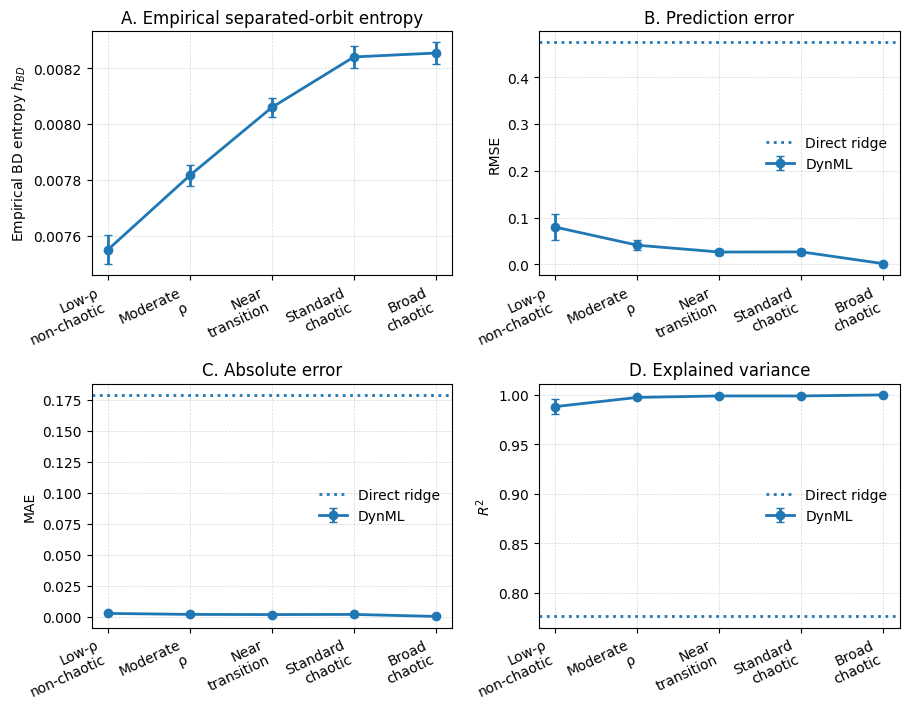

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prediction_df = pd.read_csv("fixed_N_prediction_metrics_by_parameter_regime.csv")
entropy_df = pd.read_csv("summary_fixed_N_empirical_BD_entropy_by_parameter_regime.csv")

regime_order = [
    "low_rho_nonchaotic",
    "moderate_rho",
    "near_transition",
    "standard_chaotic",
    "broad_chaotic"
]

pretty_labels = [
    "Low-ρ\nnon-chaotic",
    "Moderate\nρ",
    "Near\ntransition",
    "Standard\nchaotic",
    "Broad\nchaotic"
]

plot_eps = 0.5
plot_n = entropy_df["trajectory_length_n"].max()

dynml_df = prediction_df[prediction_df["model"] == "DynML_fixed_N"].copy()

pred_summary = (
    dynml_df
    .groupby("regime", as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        mean_pearson_r=("pearson_r", "mean"),
        std_pearson_r=("pearson_r", "std"),
        n_seeds=("seed_id", "nunique")
    )
)

for metric in ["rmse", "mae", "r2", "pearson_r"]:
    pred_summary[f"ci_{metric}"] = (
        1.96 * pred_summary[f"std_{metric}"] / np.sqrt(pred_summary["n_seeds"])
    )

entropy_plot = entropy_df[
    (entropy_df["epsilon"] == plot_eps)
    & (entropy_df["trajectory_length_n"] == plot_n)
].copy()

entropy_plot["n_seeds"] = pred_summary["n_seeds"].max()
entropy_plot["ci_entropy"] = (
    1.96 * entropy_plot["std_entropy"] / np.sqrt(entropy_plot["n_seeds"])
)

combined = pd.merge(pred_summary, entropy_plot, on="regime", how="inner")

combined["regime"] = pd.Categorical(
    combined["regime"],
    categories=regime_order,
    ordered=True
)

combined = combined.sort_values("regime")
x = np.arange(len(combined))

baseline_summary = (
    prediction_df[
        prediction_df["model"].isin(["direct_ridge_baseline", "persistence_baseline"])
    ]
    .groupby("model", as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_r2=("r2", "mean"),
        mean_pearson_r=("pearson_r", "mean")
    )
)

ridge_rmse = baseline_summary.loc[
    baseline_summary["model"] == "direct_ridge_baseline",
    "mean_rmse"
].values[0]

ridge_mae = baseline_summary.loc[
    baseline_summary["model"] == "direct_ridge_baseline",
    "mean_mae"
].values[0]

ridge_r2 = baseline_summary.loc[
    baseline_summary["model"] == "direct_ridge_baseline",
    "mean_r2"
].values[0]

fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.2))
axes = axes.flatten()

# Panel A: empirical entropy
axes[0].errorbar(
    x,
    combined["mean_entropy"],
    yerr=combined["ci_entropy"],
    marker="o",
    linewidth=2,
    capsize=3
)
axes[0].set_ylabel(r"Empirical BD entropy $h_{BD}$")
axes[0].set_title("A. Empirical separated-orbit entropy")

# Panel B: RMSE
axes[1].errorbar(
    x,
    combined["mean_rmse"],
    yerr=combined["ci_rmse"],
    marker="o",
    linewidth=2,
    capsize=3,
    label="DynML"
)
axes[1].axhline(
    ridge_rmse,
    linestyle=":",
    linewidth=2,
    label="Direct ridge"
)
axes[1].set_ylabel("RMSE")
axes[1].set_title("B. Prediction error")

# Panel C: MAE
axes[2].errorbar(
    x,
    combined["mean_mae"],
    yerr=combined["ci_mae"],
    marker="o",
    linewidth=2,
    capsize=3,
    label="DynML"
)
axes[2].axhline(
    ridge_mae,
    linestyle=":",
    linewidth=2,
    label="Direct ridge"
)
axes[2].set_ylabel("MAE")
axes[2].set_title("C. Absolute error")

# Panel D: R2
axes[3].errorbar(
    x,
    combined["mean_r2"],
    yerr=combined["ci_r2"],
    marker="o",
    linewidth=2,
    capsize=3,
    label="DynML"
)
axes[3].axhline(
    ridge_r2,
    linestyle=":",
    linewidth=2,
    label="Direct ridge"
)
axes[3].set_ylabel(r"$R^2$")
axes[3].set_title("D. Explained variance")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(pretty_labels, rotation=25, ha="right")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

axes[1].legend(frameon=False, loc="best")
axes[2].legend(frameon=False, loc="best")
axes[3].legend(frameon=False, loc="best")

plt.tight_layout()
plt.savefig("manuscript_fixed_N_regime_error_metrics.jpeg", dpi=900, bbox_inches="tight")
plt.savefig("manuscript_fixed_N_regime_error_metrics.pdf", bbox_inches="tight")
plt.show()

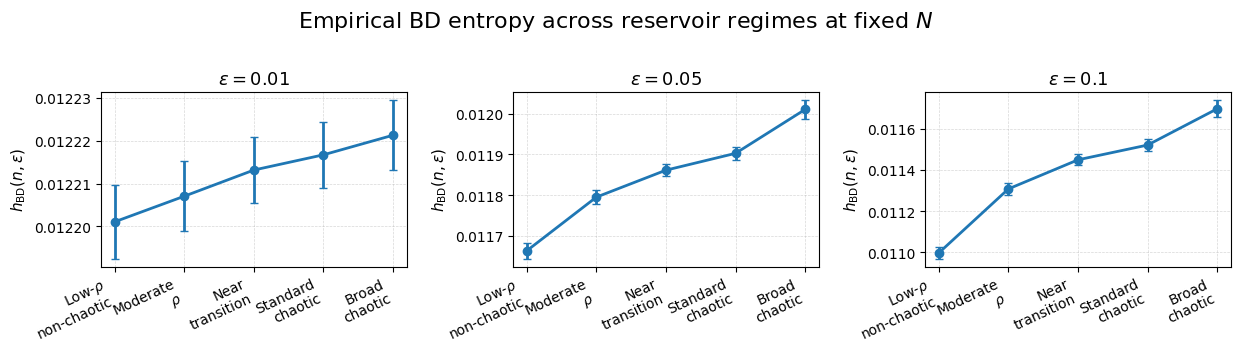

Saved:
supp_fixed_N_empirical_BD_entropy_all_eps_subplots.jpeg
supp_fixed_N_empirical_BD_entropy_all_eps_subplots.pdf


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Supplementary figure:
# Empirical BD entropy by reservoir regime across epsilon values
# ============================================================

entropy_df = pd.read_csv(
    "summary_fixed_N_empirical_BD_entropy_by_parameter_regime.csv"
)

regime_order = [
    "low_rho_nonchaotic",
    "moderate_rho",
    "near_transition",
    "standard_chaotic",
    "broad_chaotic"
]

pretty_labels = [
    "Low-$\\rho$\nnon-chaotic",
    "Moderate\n$\\rho$",
    "Near\ntransition",
    "Standard\nchaotic",
    "Broad\nchaotic"
]

# Use final trajectory length
plot_n = entropy_df["trajectory_length_n"].max()

# # Choose epsilon values to show
# eps_values_to_plot = sorted(entropy_df["epsilon"].unique())

# eps_values = [0.9, 0.5, 0.1, 0.05, 1e-2, 1e-4, 1e-6, 1e-10]
# If you want fewer panels, use this instead:
eps_values_to_plot = [0.01, 0.05, 0.1]

# Number of panels
n_eps = len(eps_values_to_plot)

# Arrange subplot grid
n_cols = 3
n_rows = int(np.ceil(n_eps / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.2 * n_cols, 3.4 * n_rows),
    sharex=True,
    sharey=False
)

axes = np.asarray(axes).flatten()

x = np.arange(len(regime_order))

for ax, eps in zip(axes, eps_values_to_plot):

    df_eps = entropy_df[
        (entropy_df["epsilon"] == eps)
        & (entropy_df["trajectory_length_n"] == plot_n)
    ].copy()

    df_eps["regime"] = pd.Categorical(
        df_eps["regime"],
        categories=regime_order,
        ordered=True
    )

    df_eps = df_eps.sort_values("regime")

    # Use seed count if available; otherwise infer from std and use 30
    if "n_seeds" in df_eps.columns:
        n_entropy_seeds = df_eps["n_seeds"].values
    elif "num_seeds" in df_eps.columns:
        n_entropy_seeds = df_eps["num_seeds"].values
    else:
        n_entropy_seeds = 30

    ci_entropy = (
        1.96 * df_eps["std_entropy"].values / np.sqrt(n_entropy_seeds)
    )

    ax.errorbar(
        x,
        df_eps["mean_entropy"].values,
        yerr=ci_entropy,
        marker="o",
        linewidth=2,
        capsize=3
    )

    ax.set_title(rf"$\epsilon={eps}$", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(pretty_labels, rotation=25, ha="right", fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    ax.set_ylabel(r"$h_{\mathrm{BD}}(n,\epsilon)$", fontsize=11)

# Hide unused axes
for ax in axes[n_eps:]:
    ax.axis("off")

fig.suptitle(
    rf"Empirical BD entropy across reservoir regimes at fixed $N$",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "supp_fixed_N_empirical_BD_entropy_all_eps_subplots.jpeg",
    dpi=900,
    bbox_inches="tight"
)

plt.savefig(
    "supp_fixed_N_empirical_BD_entropy_all_eps_subplots.pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("supp_fixed_N_empirical_BD_entropy_all_eps_subplots.jpeg")
print("supp_fixed_N_empirical_BD_entropy_all_eps_subplots.pdf")